# Hierarchical Bayesian Bradley-Terry — full analysis

Complete analysis of the VGC ranking model from the NUTS posterior. Loads the additive model
(`nuts_syn0`) as primary and the synergy model (`nuts_syn4`) for the synergy section.

**Read everything by interval, not by mean.** These are NUTS estimates, so the credible
intervals are reliable; an effect whose 90% interval crosses zero is *not* established by the
data. Effects are in log-odds and identified up to an additive constant per block (sum-to-zero
constraint), so read each coefficient relative to its block average.

Contents: convergence diagnostics · variance decomposition (`tau`) · Pokémon ranking ·
set-level effects (items, moves, abilities, natures) · player effects · team ranking ·
head-to-head · species synergy · held-out validation.

## Setup — locate inputs, copy code

In [1]:
!pip install -q numpyro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 8.3 MB/s eta 0:00:00


In [2]:
import glob, os, shutil, json, collections
import numpy as np, pandas as pd
import arviz as az, xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display
import numpyro

SRC = "/kaggle/working/src"; os.makedirs(SRC, exist_ok=True)
RESULTS = "/kaggle/working/results"; os.makedirs(RESULTS, exist_ok=True)
FIGURES = "/kaggle/working/figures"; os.makedirs(FIGURES, exist_ok=True)

for f in ("bt_bayes.py", "design_matrix.py"):
    hits = glob.glob(f"/kaggle/input/**/{f}", recursive=True)
    assert hits, f"{f} missing from the dataset"
    shutil.copy(hits[0], os.path.join(SRC, f))

def find(name):
    hits = glob.glob(f"/kaggle/input/**/{name}", recursive=True)
    assert hits, f"{name} missing from the dataset"
    return hits[0]

ALL_BLOCKS = ["species", "ability", "item", "nature", "moves"]

def load(tag):
    idata = az.from_netcdf(find(f"bt_posterior_{tag}.nc"))
    art = json.load(open(find(f"bt_artifacts_{tag}.json"), encoding="utf-8"))
    return idata, idata.posterior, art

idata, post, art = load("nuts_syn0")
cfg = art["config"]
print("config:", {k: cfg[k] for k in ("n_matches","n_players_effect","min_freq","min_player_matches","draws","chains")})
try:
    idata4, post4, art4 = load("nuts_syn4"); HAS_SYN = True; print("synergy model loaded")
except AssertionError:
    HAS_SYN = False; print("synergy model not found: section 8 skipped")

MATCHES = find("matches_clean.jsonl"); TEAMS = find("teams.jsonl")

config: {'n_matches': 17581, 'n_players_effect': 1657, 'min_freq': 5, 'min_player_matches': 8, 'draws': 800, 'chains': 4}
synergy model loaded


## 1. Convergence diagnostics
`r_hat` ~1.00 and `ess_bulk` in the hundreds+ mean the sampler converged.

In [3]:
diag = az.summary(idata, var_names=[f"tau_{b}" for b in ALL_BLOCKS] + ["tau_player", "c_side"],
                  kind="diagnostics")
display(diag[["ess_bulk", "ess_tail", "r_hat"]])
worst = max(float(az.rhat(idata, var_names=[f"beta_{b}"])[f"beta_{b}"].max()) for b in ALL_BLOCKS)
print(f"worst r_hat across all beta coefficients: {worst:.3f}")
print("side intercept c:", f"{float(post['c_side'].mean()):.3f} "
      f"[{float(post['c_side'].quantile(0.05)):.3f}, {float(post['c_side'].quantile(0.95)):.3f}]")

,ess_bulk,ess_tail,r_hat
tau_species,592.0,594.0,1.0
tau_ability,886.0,881.0,1.0
tau_item,704.0,1148.0,1.0
tau_nature,969.0,1474.0,1.0
tau_moves,1263.0,2160.0,1.0
tau_player,1135.0,1985.0,1.0
c_side,6048.0,2708.0,1.0


worst r_hat across all beta coefficients: 1.010
side intercept c: 0.038 [0.010, 0.066]


## 2. Variance decomposition — the `tau` scales
The headline result: how much each dimension moves team strength.

,mean,q5,q95
block,,,
player,0.550,0.509,0.594
ability,0.107,0.068,0.148
item,0.102,0.064,0.142
species,0.096,0.053,0.137
moves,0.077,0.063,0.093
nature,0.058,0.028,0.101


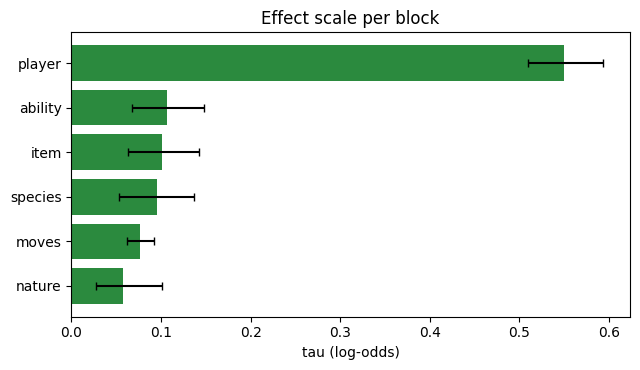

player dispersion is 5.1x the top team block


In [4]:
rows = []
for b in ALL_BLOCKS + ["player"]:
    v = post[f"tau_{b}"].values.ravel()
    rows.append((b, v.mean(), np.percentile(v,5), np.percentile(v,95)))
tau = pd.DataFrame(rows, columns=["block","mean","q5","q95"]).set_index("block").sort_values("mean", ascending=False)
display(tau.round(3))

order = tau.sort_values("mean")
fig, ax = plt.subplots(figsize=(6.5,3.8))
ax.barh(order.index, order["mean"],
        xerr=[order["mean"]-order["q5"], order["q95"]-order["mean"]], color="#2b8a3e", capsize=3)
ax.set_xlabel("tau (log-odds)"); ax.set_title("Effect scale per block")
plt.tight_layout(); plt.savefig(f"{FIGURES}/tau_blocks.png", dpi=130); plt.show()
print(f"player dispersion is {tau.loc['player','mean']/tau.drop('player')['mean'].max():.1f}x the top team block")

### Ranking helpers

In [5]:
def summarize(post_, block):
    da = post_[f"beta_{block}"].stack(sample=("chain","draw")); v = da.values
    df = pd.DataFrame({"mean": v.mean(1), "q5": np.percentile(v,5,axis=1), "q95": np.percentile(v,95,axis=1)},
                      index=[str(x) for x in da[block].values])
    df["robust"] = (df["q5"] > 0) | (df["q95"] < 0)
    return df.sort_values("mean", ascending=False)

def forest(df, title, n=20, fname=None):
    top = pd.concat([df.head(n), df.tail(n)]) if len(df) > 2*n else df
    y = np.arange(len(top))[::-1]
    colors = ["#c92a2a" if r else "#adb5bd" for r in top["robust"]]
    fig, ax = plt.subplots(figsize=(7, max(4, len(top)*0.28)))
    ax.errorbar(top["mean"], y, xerr=[top["mean"]-top["q5"], top["q95"]-top["mean"]], fmt="none", ecolor="#ced4da")
    ax.scatter(top["mean"], y, c=colors, s=24, zorder=3)
    ax.axvline(0, color="grey", lw=0.8, ls="--")
    ax.set_yticks(y); ax.set_yticklabels(top.index, fontsize=8)
    ax.set_title(title); ax.set_xlabel("effect (log-odds) — red = interval clears zero")
    plt.tight_layout()
    if fname: plt.savefig(f"{FIGURES}/{fname}", dpi=130)
    plt.show()

## 3. Pokémon ranking (species effect)

robust species (interval clears 0): 0 of 219


,mean,q5,q95,robust
Kangaskhan,0.107,-0.026,0.266,False
Archaludon,0.102,-0.024,0.248,False
Eternal Flower Floette,0.100,-0.019,0.232,False
Charizard,0.096,-0.017,0.218,False
Froslass,0.094,-0.032,0.238,False
Whimsicott,0.085,-0.015,0.191,False
Gardevoir,0.083,-0.043,0.235,False
Hydreigon,0.076,-0.043,0.205,False
Milotic,0.075,-0.057,0.220,False
Armarouge,0.075,-0.073,0.247,False


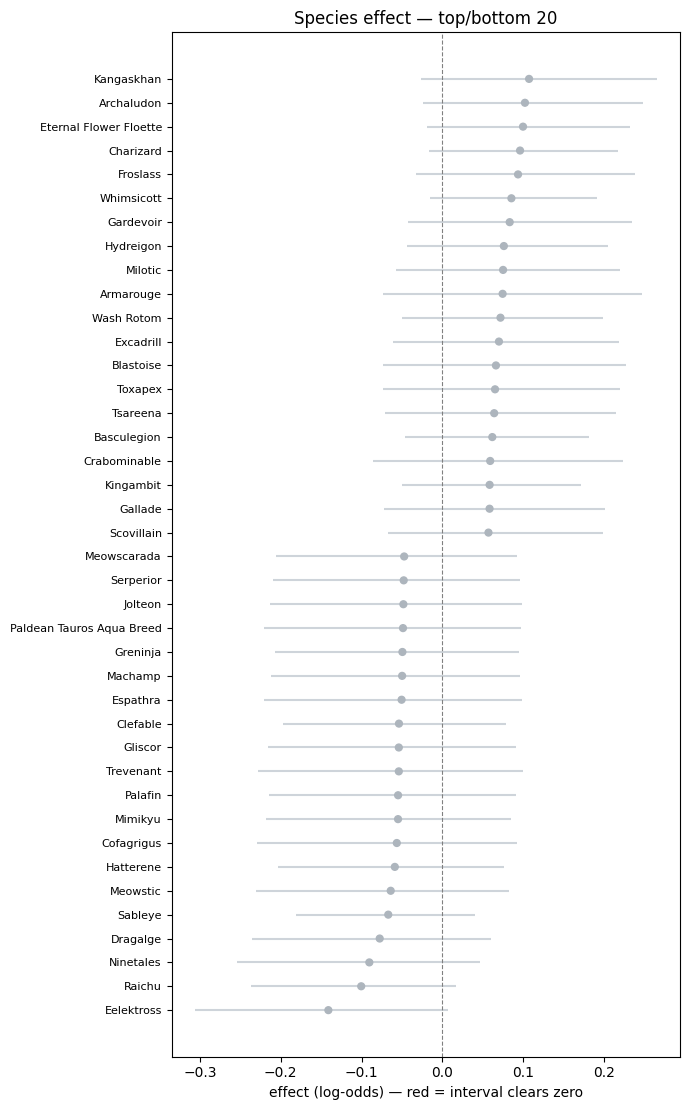

In [6]:
sp = summarize(post, "species")
print(f"robust species (interval clears 0): {int(sp['robust'].sum())} of {len(sp)}")
display(sp.head(20).round(3))
forest(sp, "Species effect — top/bottom 20", fname="ranking_species.png")
sp.to_csv(f"{RESULTS}/ranking_species_nuts.csv")

## 4. Set-level effects — items, moves, abilities, natures

== item: 7 robust of 162 ==


,mean,q5,q95,robust
Floettite,0.143,-0.004,0.311,False
Venusaurite,0.143,0.018,0.282,True
Light Clay,0.110,0.007,0.220,True
Spell Tag,0.107,-0.033,0.266,False
Passho Berry,0.105,0.000,0.212,True
Black Glasses,0.083,-0.002,0.170,False
Blastoisinite,0.078,-0.064,0.238,False
Dragoninite,0.074,-0.055,0.210,False
Raichunite Y,0.066,-0.071,0.208,False
Gardevoirite,0.064,-0.077,0.219,False


== moves: 12 robust of 420 ==


,mean,q5,q95,robust
Encore,0.121,0.053,0.190,True
Weather Ball,0.115,0.043,0.189,True
Quick Guard,0.112,0.013,0.220,True
Swords Dance,0.107,0.031,0.185,True
Stomping Tantrum,0.100,0.033,0.167,True
Draining Kiss,0.089,-0.004,0.183,False
Snarl,0.086,-0.008,0.184,False
Thunderbolt,0.082,0.017,0.150,True
Gunk Shot,0.081,-0.025,0.193,False
Rage Powder,0.080,-0.017,0.181,False


== ability: 2 robust of 168 ==


,mean,q5,q95,robust
Moody,0.141,-0.009,0.309,False
Unnerve,0.139,0.025,0.258,True
Scrappy,0.138,-0.011,0.300,False
Competitive,0.123,-0.014,0.269,False
Sand Rush,0.108,-0.028,0.254,False
Stamina,0.103,-0.032,0.247,False
Flame Body,0.098,-0.057,0.283,False
Poison Touch,0.098,-0.020,0.228,False
Friend Guard,0.097,-0.040,0.239,False
Telepathy,0.093,-0.061,0.264,False


== nature: 3 robust of 23 ==


,mean,q5,q95,robust
Calm,0.091,0.027,0.160,True
Modest,0.064,0.023,0.110,True
Bold,0.055,0.006,0.109,True
Adamant,0.030,-0.010,0.072,False
Jolly,0.017,-0.025,0.062,False
Brave,0.011,-0.046,0.071,False
Timid,0.006,-0.034,0.053,False
Impish,0.003,-0.052,0.060,False
Naive,0.002,-0.079,0.089,False
Mild,0.001,-0.093,0.092,False


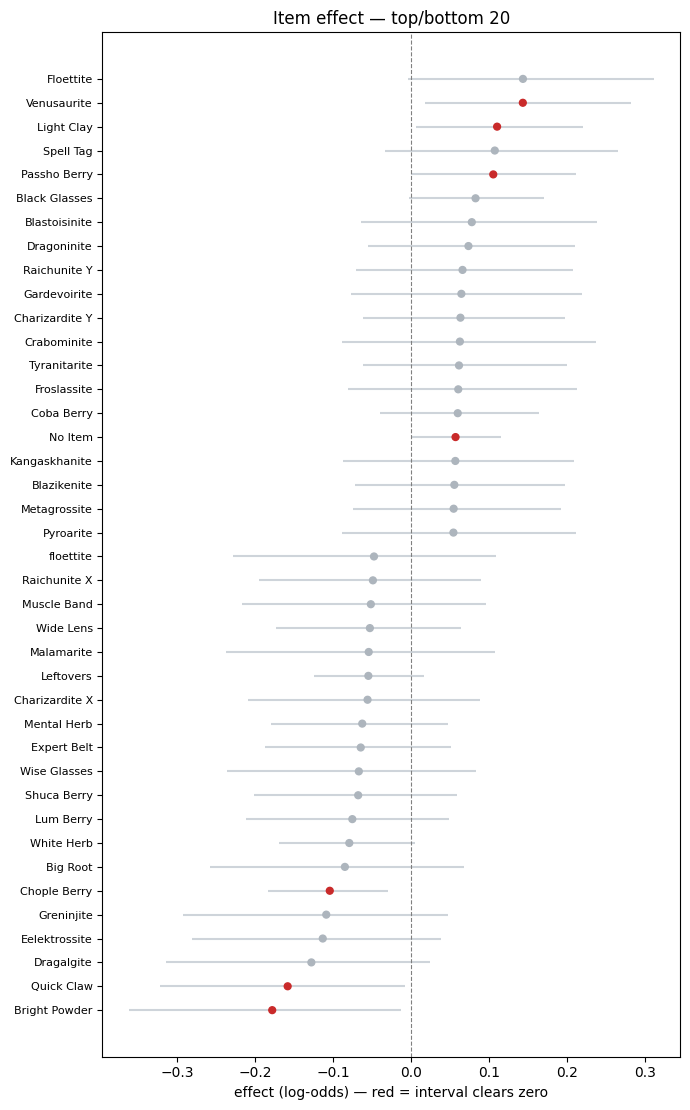

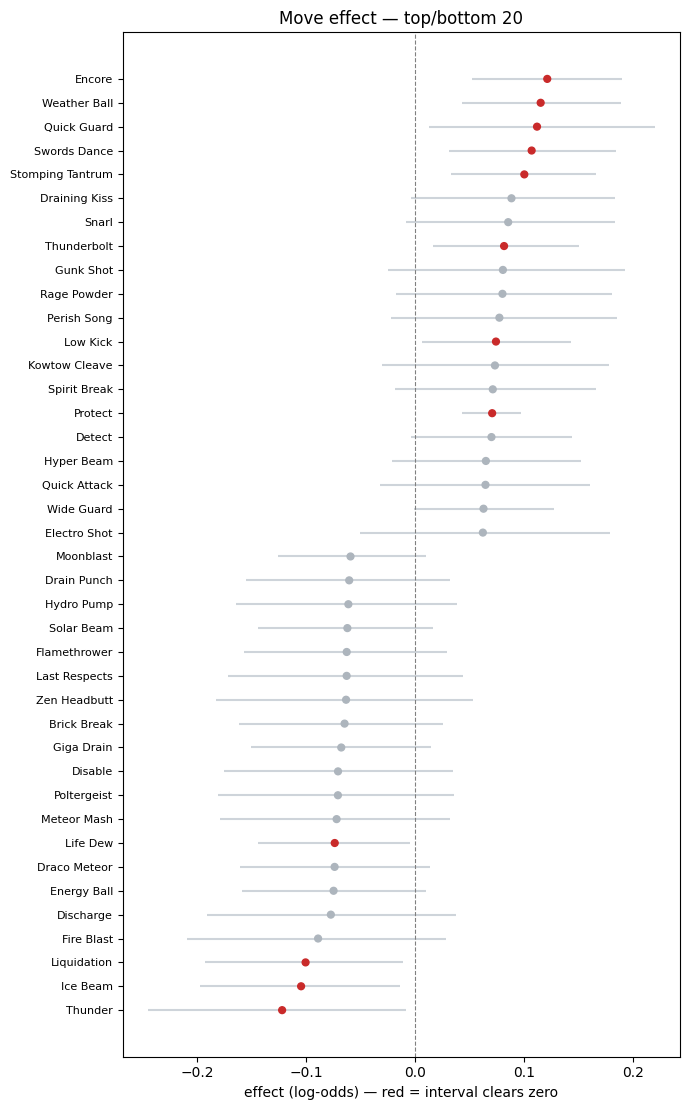

In [7]:
for block in ["item","moves","ability","nature"]:
    df = summarize(post, block)
    print(f"== {block}: {int(df['robust'].sum())} robust of {len(df)} ==")
    display(df.head(12).round(3))
    df.to_csv(f"{RESULTS}/ranking_{block}_nuts.csv")
forest(summarize(post,"item"),  "Item effect — top/bottom 20",  fname="ranking_item.png")
forest(summarize(post,"moves"), "Move effect — top/bottom 20",  fname="ranking_moves.png")

## 5. Player effects
`lam_player` isolates pilot skill. Caveat: a player who always brings the same list makes skill
and team strength collinear, so read individual values with care.

In [8]:
la = post["lam_player"].stack(sample=("chain","draw")); v = la.values
lam = pd.DataFrame({"mean": v.mean(1), "q5": np.percentile(v,5,axis=1), "q95": np.percentile(v,95,axis=1)},
                   index=[str(x) for x in la["player"].values])
lam["robust"] = (lam["q5"] > 0) | (lam["q95"] < 0)
lam = lam.sort_values("mean", ascending=False)
print(f"players modelled: {len(lam)} (threshold {cfg['min_player_matches']} matches)")
print(f"robust player effects: {int(lam['robust'].sum())} | dispersion sd = {lam['mean'].std():.3f}")
display(lam.head(15).round(3))

players modelled: 1657 (threshold 8 matches)
robust player effects: 141 | dispersion sd = 0.365


,mean,q5,q95,robust
force_india,1.287,0.751,1.822,True
wb_vg,1.271,0.802,1.765,True
root2iris,1.111,0.521,1.705,True
silvereignn,1.047,0.465,1.652,True
snorlaxpikachu1,1.027,0.521,1.541,True
mollusck,1.020,0.321,1.750,True
magnus309,1.002,0.425,1.581,True
vgcorner,0.987,0.305,1.680,True
daredevilzz26,0.986,0.445,1.544,True
conia,0.979,0.405,1.555,True


## 6. Team ranking (the target)
Posterior strength `s(team)`, pilot excluded. Restricted to teams seen at least `MIN_OCC` times.

In [9]:
def team_key(team):
    return tuple(sorted((m["species"], m.get("item"), m.get("ability"), m.get("nature"),
                         tuple(sorted(m.get("moves", [])))) for m in team))

rows = [json.loads(l) for l in open(TEAMS, encoding="utf-8")]
uniq = {}
for r in rows:
    d = uniq.setdefault(team_key(r["team"]), {"team": r["team"], "n": 0}); d["n"] += 1
MIN_OCC = 5
cand = [v for v in uniq.values() if v["n"] >= MIN_OCC]
print(f"{len(cand)} teams seen >= {MIN_OCC} times (of {len(uniq)} unique)")

def strength_matrix(post_, teams):
    S = post_["c_side"].stack(sample=("chain","draw")).shape[0]
    out = np.zeros((len(teams), S))
    for b in ALL_BLOCKS:
        B = post_[f"beta_{b}"].stack(sample=("chain","draw")).values
        idx = {str(l): i for i, l in enumerate(post_[b].values)}
        C = np.zeros((len(teams), B.shape[0]))
        for i, v in enumerate(teams):
            cnt = collections.Counter()
            for mon in v["team"]:
                if b == "moves":
                    for mvv in mon["moves"]: cnt[mvv] += 1
                else: cnt[mon[b]] += 1
            for lv, k in cnt.items():
                j = idx.get(str(lv))
                if j is not None: C[i, j] += k
        out += C @ B
    if "V_species" in post_:
        V = post_["V_species"].stack(sample=("chain","draw")).values
        idx = {str(l): i for i, l in enumerate(post_["species"].values)}
        for i, v in enumerate(teams):
            cnt = collections.Counter(m["species"] for m in v["team"])
            sc = np.zeros(V.shape[0])
            for lv, k in cnt.items():
                j = idx.get(str(lv))
                if j is not None: sc[j] += k
            z = np.einsum("s,sfS->fS", sc, V); self_t = np.einsum("s,sfS->S", sc, V**2)
            out[i] += 0.5*((z**2).sum(0) - self_t)
    return out

M = strength_matrix(post, cand)
rank = pd.DataFrame({
    "team": [" / ".join(m["species"] for m in v["team"]) for v in cand],
    "n": [v["n"] for v in cand],
    "mean": M.mean(1), "q5": np.percentile(M,5,axis=1), "q95": np.percentile(M,95,axis=1),
})
rank["_team"] = [v["team"] for v in cand]
rank = rank.sort_values("mean", ascending=False).reset_index(drop=True)
display(rank.head(20)[["team","n","mean","q5","q95"]].round(3))
rank.drop(columns="_team").to_csv(f"{RESULTS}/ranking_teams_nuts.csv", index=False)

95 teams seen >= 5 times (of 5393 unique)


,team,n,mean,q5,q95
0,Sneasler / Blastoise / Kingambit / Incineroar ...,7,2.048,1.691,2.412
1,Blastoise / Delphox / Sneasler / Incineroar / ...,5,1.899,1.554,2.257
2,Delphox / Eternal Flower Floette / Sinistcha /...,7,1.815,1.484,2.158
3,Froslass / Scovillain / Basculegion / Kingambi...,8,1.815,1.460,2.191
4,Sinistcha / Kingambit / Sneasler / Eternal Flo...,8,1.808,1.476,2.149
5,Froslass / Scovillain / Sneasler / Kingambit /...,7,1.681,1.342,2.039
6,Charizard / Eternal Flower Floette / Aegislash...,5,1.628,1.216,2.051
7,Froslass / Scovillain / Basculegion / Kingambi...,5,1.623,1.281,1.984
8,Swampert / Pelipper / Archaludon / Venusaur / ...,7,1.587,1.227,1.946
9,Charizard / Sylveon / Aerodactyl / Farigiraf /...,5,1.585,1.256,1.917


### Best team — complete sets

,species,ability,item,nature,moves
0,Sneasler,Poison Touch,Focus Sash,Jolly,"Poison Jab, Close Combat, Fake Out, Quick Guard"
1,Blastoise,Rain Dish,Blastoisinite,Modest,"Dark Pulse, Water Spout, Shell Smash, Protect"
2,Kingambit,Defiant,Black Glasses,Adamant,"Kowtow Cleave, Sucker Punch, Swords Dance, Pro..."
3,Incineroar,Intimidate,Sitrus Berry,Careful,"Flare Blitz, Helping Hand, Parting Shot, Fake Out"
4,Delphox,Blaze,Delphoxite,Modest,"Heat Wave, Nasty Plot, Psyshock, Protect"
5,Sinistcha,Hospitality,Kasib Berry,Bold,"Matcha Gotcha, Rage Powder, Trick Room, Protect"


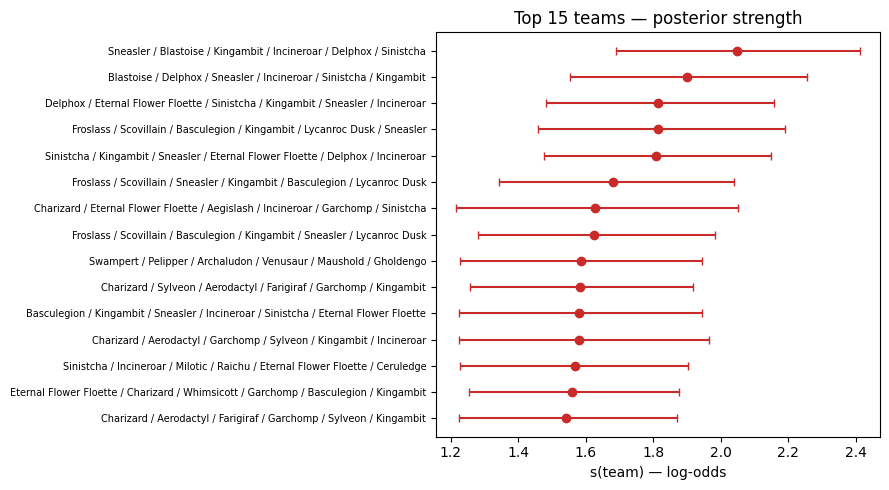

In [10]:
best = rank.iloc[0]["_team"]
display(pd.DataFrame([{"species": m["species"], "ability": m.get("ability"), "item": m.get("item"),
                       "nature": m.get("nature"), "moves": ", ".join(m.get("moves", []))} for m in best]))
top = rank.head(15)[::-1]; yy = np.arange(len(top))
fig, ax = plt.subplots(figsize=(9,5))
ax.errorbar(top["mean"], yy, xerr=[top["mean"]-top["q5"], top["q95"]-top["mean"]], fmt="o", color="#c92a2a", capsize=3)
ax.set_yticks(yy); ax.set_yticklabels(top["team"], fontsize=7)
ax.set_title("Top 15 teams — posterior strength"); ax.set_xlabel("s(team) — log-odds")
plt.tight_layout(); plt.savefig(f"{FIGURES}/ranking_teams.png", dpi=130); plt.show()

## 7. Head-to-head

A: Sneasler / Blastoise / Kingambit / Incineroar / Delphox / Sinistcha
B: Blastoise / Delphox / Sneasler / Incineroar / Sinistcha / Kingambit
P(A beats B) = 0.537  [0.484, 0.590]


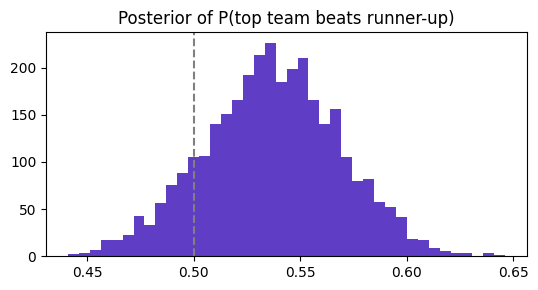

In [11]:
order = np.argsort(-M.mean(1))
pAB = 1/(1+np.exp(-(M[order[0]] - M[order[1]])))
print("A:", rank.iloc[0]["team"]); print("B:", rank.iloc[1]["team"])
print(f"P(A beats B) = {pAB.mean():.3f}  [{np.percentile(pAB,5):.3f}, {np.percentile(pAB,95):.3f}]")
fig, ax = plt.subplots(figsize=(5.5,3))
ax.hist(pAB, bins=40, color="#5f3dc4"); ax.axvline(0.5, color="grey", ls="--")
ax.set_title("Posterior of P(top team beats runner-up)"); plt.tight_layout(); plt.show()

## 8. Species synergy (synergy model)

In [12]:
if HAS_SYN:
    V = post4["V_species"].stack(sample=("chain","draw")).values
    sp_labels = [str(x) for x in post4["species"].values]; idx = {l:i for i,l in enumerate(sp_labels)}
    pairs = collections.Counter()
    for r in rows:
        specs = sorted(set(m["species"] for m in r["team"]))
        for i in range(len(specs)):
            for j in range(i+1, len(specs)):
                pairs[(specs[i], specs[j])] += 1
    recs = []
    for (a,b), c in pairs.items():
        if c < 5 or a not in idx or b not in idx: continue
        d = np.einsum("fS,fS->S", V[idx[a]], V[idx[b]])
        recs.append((a, b, c, d.mean(), np.percentile(d,5), np.percentile(d,95)))
    syn = pd.DataFrame(recs, columns=["species_1","species_2","n","mean","q5","q95"])
    syn["robust"] = (syn["q5"]>0)|(syn["q95"]<0)
    print(f"{int(syn['robust'].sum())} robust pairs of {len(syn)}")
    print("== strongest positive (cores) =="); display(syn.sort_values("mean", ascending=False).head(12).round(3))
    print("== strongest negative =="); display(syn.sort_values("mean").head(8).round(3))
    syn.sort_values("mean", ascending=False).to_csv(f"{RESULTS}/synergy_pairs.csv", index=False)
else:
    print("synergy model not loaded — skipped")

4 robust pairs of 1936
== strongest positive (cores) ==


,species_1,species_2,n,mean,q5,q95,robust
196,Archaludon,Grimmsnarl,495,0.095,0.003,0.206,True
95,Kingambit,Sneasler,567,0.091,0.019,0.172,True
94,Kingambit,Sinistcha,388,0.089,0.019,0.170,True
92,Eternal Flower Floette,Kingambit,571,0.080,0.007,0.162,True
840,Gengar,Grimmsnarl,32,0.079,-0.027,0.204,False
314,Sinistcha,Tyranitar,136,0.078,-0.013,0.194,False
312,Gholdengo,Tyranitar,42,0.076,-0.014,0.197,False
51,Blaziken,Kingambit,199,0.075,-0.014,0.176,False
718,Gholdengo,Scovillain,45,0.074,-0.023,0.207,False
270,Charizard,Hydreigon,161,0.070,-0.016,0.175,False


== strongest negative ==


,species_1,species_2,n,mean,q5,q95,robust
764,Grimmsnarl,Kingambit,65,-0.081,-0.181,0.008,False
592,Archaludon,Kingambit,56,-0.081,-0.192,0.014,False
1640,Eternal Flower Floette,Gengar,5,-0.077,-0.209,0.027,False
242,Alolan Ninetales,Charizard,21,-0.072,-0.194,0.021,False
10,Farigiraf,Kingambit,504,-0.071,-0.153,0.003,False
648,Archaludon,Sneasler,143,-0.071,-0.181,0.016,False
927,Blaziken,Farigiraf,59,-0.071,-0.180,0.014,False
406,Eternal Flower Floette,Grimmsnarl,134,-0.069,-0.168,0.020,False


## 9. Held-out validation (NUTS refit on GPU)
Everything above reads the saved posteriors and is instant. This section is the slow one: it
splits the data, **refits on the training half with NUTS on GPU** (subprocess), and scores the
held-out half. This produces the rigorous NUTS held-out log-loss.

The refit takes a while; sections 1–8 are already complete and downloadable before it finishes.

In [13]:
# split and write train/test
matches = [json.loads(l) for l in open(MATCHES, encoding="utf-8")]
matches = [m for m in matches if m.get("label") is not None]
rng = np.random.default_rng(0)
perm = rng.permutation(len(matches)); cut = int(0.85*len(matches))
train = [matches[i] for i in perm[:cut]]; test = [matches[i] for i in perm[cut:]]
TRAIN = "/kaggle/working/train.jsonl"; TEST = "/kaggle/working/test.jsonl"
with open(TRAIN,"w",encoding="utf-8") as f:
    for m in train: f.write(json.dumps(m)+"\n")
with open(TEST,"w",encoding="utf-8") as f:
    for m in test: f.write(json.dumps(m)+"\n")
print(f"train {len(train)} | test {len(test)}")

train 14943 | test 2638


In [14]:
!cd /kaggle/working && python src/bt_bayes.py \
    --matches /kaggle/working/train.jsonl \
    --method nuts --sampler numpyro \
    --draws 500 --tune 500 --chains 2 \
    --min-freq 5 --min-player-matches 8 --target-accept 0.9 \
    --out-dir /kaggle/working/models --tag heldout_train

dimensioni blocco: {'species': 219, 'ability': 163, 'item': 159, 'nature': 23, 'moves': 413} | giocatori con effetto: 1300 (soglia 8 match) | match: 14943
campionatore NUTS: numpyro | tune=500 draws=500 chains=2 target_accept=0.9
Running chain 0: 100%|██████████████████████| 1000/1000 [02:44<00:00,  6.08it/s]

Running chain 1: 100%|██████████████████████| 1000/1000 [02:54<00:00,  5.72it/s]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[2,500,218], float64[2,500,162], float64[2,500,158], float64[2,500,22], float64[2,500,412], float64[2,500,1299].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.0800

In [15]:
# predict on held-out (numpy only, no JAX in kernel)
import sys; sys.path.insert(0, "/kaggle/working/src")
from design_matrix import team_counts, ALL_BLOCKS as AB

itr = az.from_netcdf("/kaggle/working/models/bt_posterior_heldout_train.nc")
atr = json.load(open("/kaggle/working/models/bt_artifacts_heldout_train.json", encoding="utf-8"))
Pt = itr.posterior
betas = {b: Pt[f"beta_{b}"].stack(s=("chain","draw")).values for b in AB}
lam = Pt["lam_player"].stack(s=("chain","draw")).values
lam_full = np.vstack([lam, np.zeros((1, lam.shape[1]))])
cside = Pt["c_side"].stack(s=("chain","draw")).values.ravel()
npl = lam.shape[0]
vocab = {b: {name:i for i,name in enumerate(atr["vocab"][b])} for b in AB}
players = {name:i for i,name in enumerate(atr["players"])}

def predict(ms):
    out = np.empty(len(ms))
    for k, m in enumerate(ms):
        eta = cside.copy()
        c1, c2 = team_counts(m["team1"]), team_counts(m["team2"])
        for b in AB:
            vb = vocab[b]; vec = np.zeros(len(vb))
            for lv,n in c1[b].items():
                j = vb.get(lv)
                if j is not None: vec[j] += n
            for lv,n in c2[b].items():
                j = vb.get(lv)
                if j is not None: vec[j] -= n
            eta = eta + vec @ betas[b]
        i1 = players.get(m["player1"], npl); i2 = players.get(m["player2"], npl)
        eta = eta + lam_full[i1] - lam_full[i2]
        out[k] = (1/(1+np.exp(-eta))).mean()
    return out

test = [json.loads(l) for l in open(TEST, encoding="utf-8")]
p = predict(test); y = np.array([m["label"] for m in test])
eps = 1e-9
ll = -np.mean(y*np.log(p+eps)+(1-y)*np.log(1-p+eps)); acc = np.mean((p>0.5)==y)
print(f"held-out matches: {len(y)}")
print(f"NUTS held-out log-loss: {ll:.4f}  (coin flip {np.log(2):.4f})")
print(f"NUTS held-out accuracy: {acc:.4f}")

held-out matches: 2638
NUTS held-out log-loss: 0.6584  (coin flip 0.6931)
NUTS held-out accuracy: 0.6005


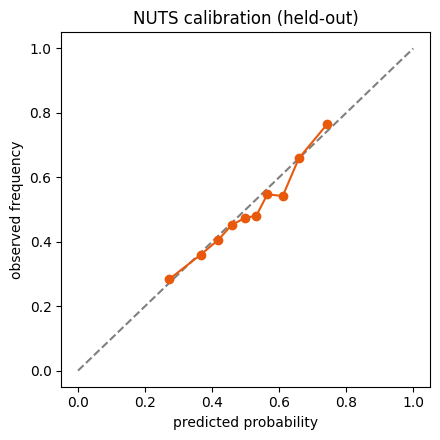

In [16]:
# calibration
bins = np.quantile(p, np.linspace(0,1,11)); bins[0], bins[-1] = 0, 1
mid, obs = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    sel = (p>=lo) & (p<hi)
    if sel.sum(): mid.append(p[sel].mean()); obs.append(y[sel].mean())
fig, ax = plt.subplots(figsize=(4.5,4.5))
ax.plot([0,1],[0,1],"--",color="grey"); ax.plot(mid, obs, "o-", color="#e8590c")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("NUTS calibration (held-out)")
plt.tight_layout(); plt.savefig(f"{FIGURES}/calibration_nuts.png", dpi=130); plt.show()

## Summary

- **Player skill dominates** the variance; no single species is a robust best pick; choices
  (moves, items, natures) are more identifiable than species.
- **Team strengths** are close at the top and pilot-free; the head-to-head brushes a coin flip.
- **Synergy** is real but small, concentrated in a few known cores.
- **Held-out** performance beats chance modestly — the single match stays near a coin flip even
  given both teamlists and pilot history.

